<h1>Regularisation</h1>

It minimises overfitting (analysis/model fitting too closely to a particular dataset) and is executed during the model fitting step. If a model is able to accurately make predictions on one set of data but poorly on unseen/different datas we have overfitting. 

<h2>Overfitting Signs</h2>
 - Fits training data well but performs significantly worse on test data
 - It has more parameters than needed, high model complexity
 - It might be fitting for features that are multi-collinear 
 - Fitting noise in the data treating it as feature.

It is also considered an embeded feature selection method because it is done when parameters of the model are being calculated. 

Regularisation helps makes models more generalisable. 

<h2>Demonstrating Overfitting</h2>

In [30]:
import pandas as pd

df = pd.read_csv("/Users/jai/Documents/GitHub/MachineLearningPortfolio/Regularisation/student_math.csv")

y = df["Final_Grade"]
X = df.drop(columns=["Final_Grade"])


In [31]:
num_features = len(X.columns)
print(f"Number of Features: {num_features}")

Number of Features: 41


Large number of features - fitting a model on this many features without EDA and feature selection suggests the model with overfit the data. 

To demonstrate overfitting I will first fit a model with the full feature set and compare it to a model with fewer features

In [42]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the model on training data
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

# MSE on training Data
import numpy as np

pred_train = linear_regression.predict(X_train)
MSE_train = np.mean((pred_train - y_train)**2)
print(f"Training set mean squared error: {MSE_train}")

# MSE on test data
pred_test = linear_regression.predict(X_test)
MSE_test = np.mean((pred_test - y_test)**2)
print(f"Test set mean squared error: {MSE_test}")

predictors = X.columns
coef = pd.Series(linear_regression.coef_,predictors).sort_values()

Training set mean squared error: 2.706734332107095
Test set mean squared error: 4.993008659924371


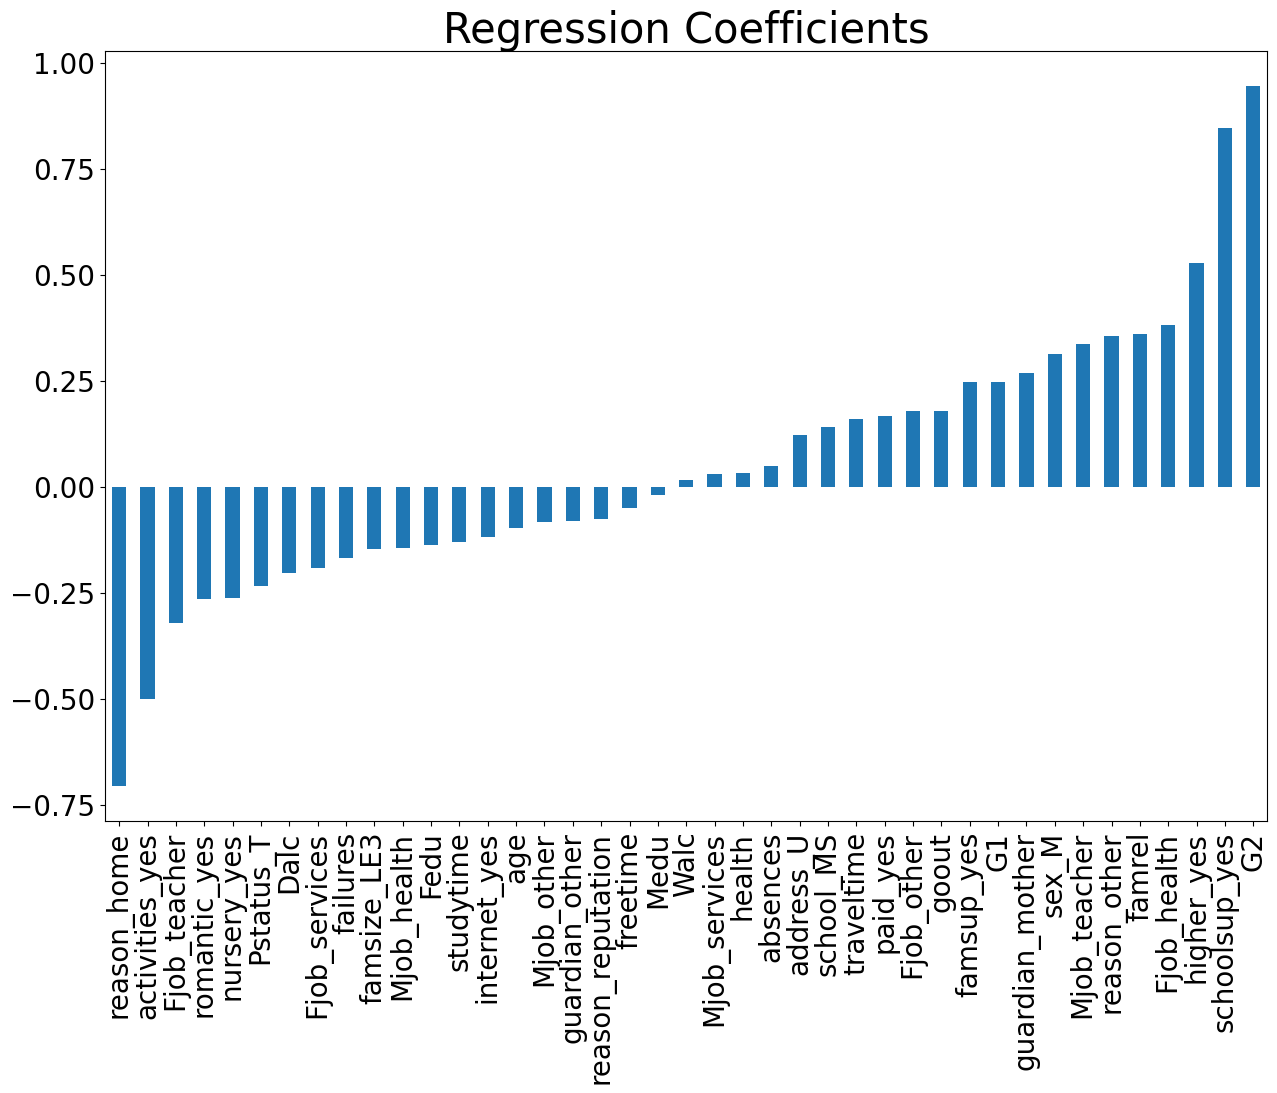

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15,10))
coef.plot(kind='bar', fontsize = 20)
plt.title ("Regression Coefficients", fontsize = 30)
plt.show()

In linear regression, the loss function (MSE) is minimised by OLS but this does not always generalise well. Regularisation can help this as seen below.

[77.30856619 18.87896326]


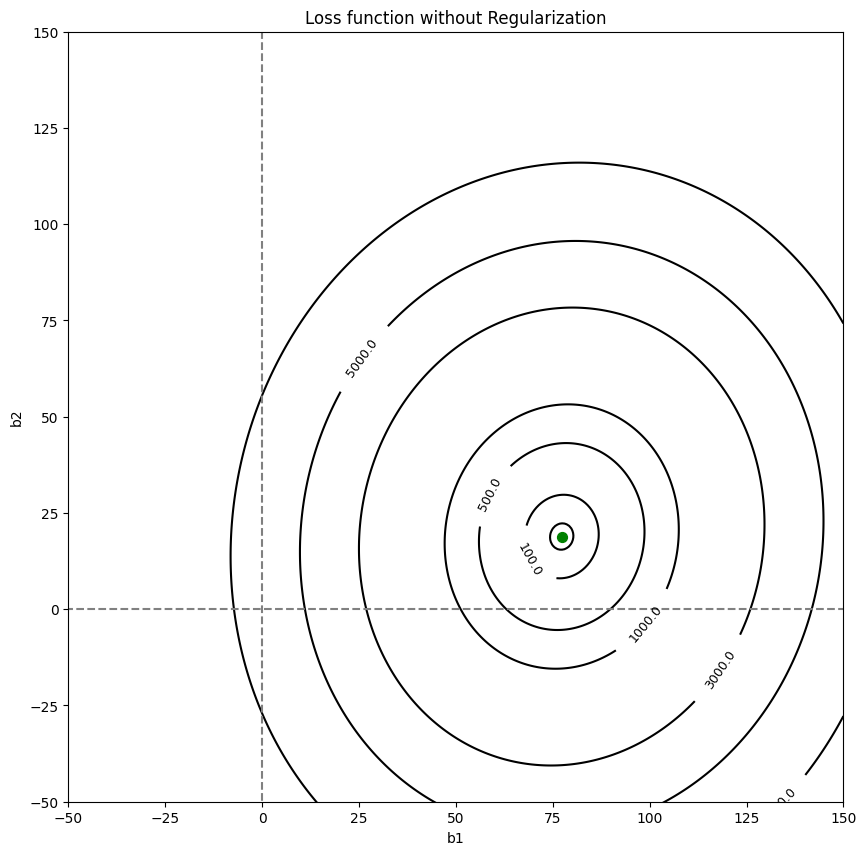

In [48]:
from sklearn import datasets
data, y, coefficients = datasets.make_regression(n_samples = 100, n_features = 2, coef = True, random_state = 23)
x1 = data[:,0]
x2 = data[:,1]

# 1. Print the coefficients
print(coefficients)

# 2. Loss Function
def loss_function(b1,b2,y,x1,x2):
    error = y - (b1*x1 + b2*x2)
    loss = np.mean(error**2)
    return loss

# 3. Plot loss function for data

def plot_loss_function(b1,b2,y,x1,x2):
    loss = np.asarray([[loss_function(i,j,y,x1,x2) for i in b1] for j in b2])
    fig, ax = plt.subplots(figsize = (10,10))
    CS = ax.contour(b1, b2, loss, levels = [0,10, 100, 500, 1000, 3000, 5000, 8000], colors='k')
    ax.clabel(CS, fontsize=9,fmt='%1.1f', inline=True)
    ax.set_title('Loss function without Regularization')
    plt.plot([0,0,0,0,0], [-150,0,10,50,150], color = 'grey', linestyle = 'dashed')
    plt.plot([-150,0,10,50,150],[0,0,0,0,0], color = 'grey', linestyle = 'dashed')
    plt.xlim(-50,150)
    plt.ylim(-50,150)
    plt.xlabel('b1')
    plt.ylabel('b2')
    return CS

b1 = np.linspace(-150, 150, 501)
b2 = np.linspace(-150, 150, 501)
contour_plot = plot_loss_function(b1,b2,y,x1,x2)


# 4. Plot the best fit coefficients
best_fit_b1 = coefficients[0]
best_fit_b2 = coefficients[1]
plt.scatter(best_fit_b1, best_fit_b2, s = 50, color = 'green')
plt.show()

Each ellipse in this plot represents the points where the loss function has the same value. The larger the ellipse, the higher the value of loss for all the points (b1,b2) that fall on the ellipse, as we can see from the labels on the contours.

Following this logic, the center of this set of concentric ellipses should represent the minimum value of the loss function and the value of the coefficients (b1,b2) at this point should be the solution of the regression problem and represent the best fit for our data.

<h2>Regularisation Term</h2>